In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
plt.rcParams["figure.figsize"] = (15,4)

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/aakashshah3799
/kaggle/input/datasets/aakashshah3799/mit-bih-arrhythmia-database
/kaggle/input/datasets/aakashshah3799/mit-bih-arrhythmia-database/mitbih_database
/kaggle/input/datasets/aakashshah3799/mit-bih-arrhythmia-database/mitbih_database/mitbih_database


In [4]:
dataset_path = "/kaggle/input/datasets/aakashshah3799/mit-bih-arrhythmia-database/mitbih_database/mitbih_database"

files = os.listdir(dataset_path)

print("Number of files:", len(files))
print(files[:10])

Number of files: 96
['112annotations.txt', '233.csv', '108.csv', '118annotations.txt', '231.csv', '207.csv', '115annotations.txt', '108annotations.txt', '123annotations.txt', '102annotations.txt']


In [5]:
record = pd.read_csv(
    f"{dataset_path}/100.csv",
    low_memory=False
)

In [6]:
record.head()


,'sample #','MLII','V5'
0,0,995,1011
1,1,995,1011
2,2,995,1011
3,3,995,1011
4,4,995,1011


In [7]:
print(record.shape)

(650000, 3)


In [8]:
record.head()

,'sample #','MLII','V5'
0,0,995,1011
1,1,995,1011
2,2,995,1011
3,3,995,1011
4,4,995,1011


In [9]:
record.tail()

,'sample #','MLII','V5'
649995,649995,1009,928
649996,649996,935,942
649997,649997,889,951
649998,649998,871,957
649999,649999,768,1024


In [10]:
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   'sample #'  650000 non-null  int64
 1   'MLII'      650000 non-null  int64
 2   'V5'        650000 non-null  int64
dtypes: int64(3)
memory usage: 14.9 MB


In [11]:
record.describe()

,'sample #','MLII','V5'
count,650000.000000,650000.000000,650000.000000
mean,324999.500000,962.740205,985.793114
std,187638.981824,38.639938,29.642668
min,0.000000,481.000000,531.000000
25%,162499.750000,946.000000,971.000000
50%,324999.500000,957.000000,983.000000
75%,487499.250000,970.000000,995.000000
max,649999.000000,1311.000000,1269.000000


In [12]:
record.isnull().sum()

'sample #'    0
'MLII'        0
'V5'          0
dtype: int64

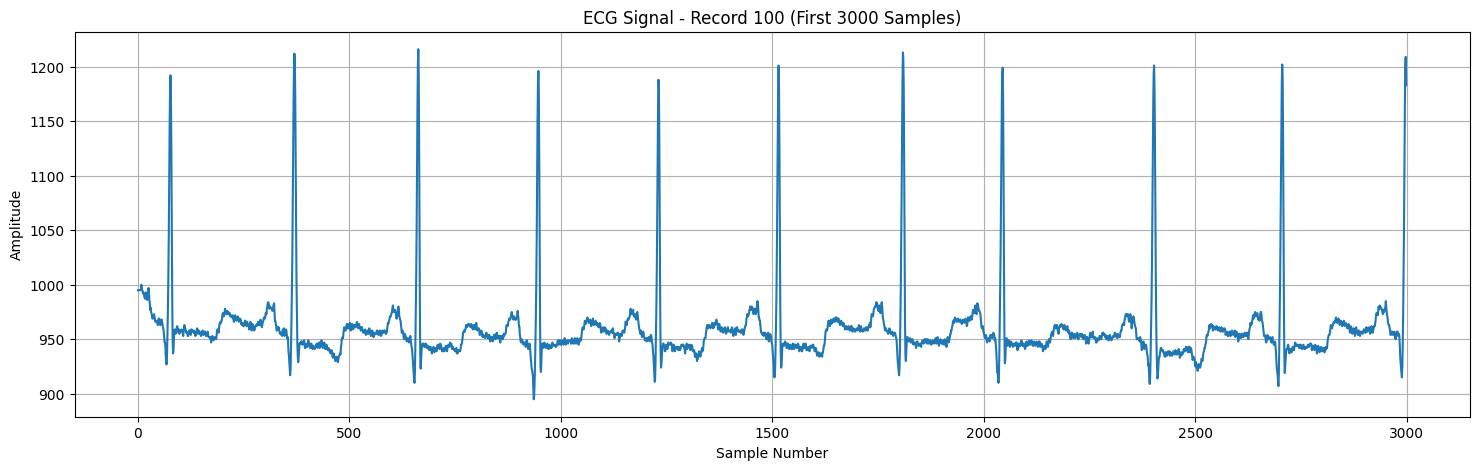

In [13]:
plt.figure(figsize=(18,5))

plt.plot(record["'MLII'"][:3000])

plt.title("ECG Signal - Record 100 (First 3000 Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [14]:
annotation_path = f"{dataset_path}/100annotations.txt"

with open(annotation_path, "r") as file:
    for i in range(20):
        print(file.readline().strip())

Time   Sample #  Type  Sub Chan  Num	Aux
0:00.050       18     +    0    0    0	(N
0:00.214       77     N    0    0    0
0:01.028      370     N    0    0    0
0:01.839      662     N    0    0    0
0:02.628      946     N    0    0    0
0:03.419     1231     N    0    0    0
0:04.208     1515     N    0    0    0
0:05.025     1809     N    0    0    0
0:05.678     2044     A    0    0    0
0:06.672     2402     N    0    0    0
0:07.517     2706     N    0    0    0
0:08.328     2998     N    0    0    0
0:09.117     3282     N    0    0    0
0:09.889     3560     N    0    0    0
0:10.728     3862     N    0    0    0
0:11.583     4170     N    0    0    0
0:12.406     4466     N    0    0    0
0:13.233     4764     N    0    0    0
0:14.056     5060     N    0    0    0


In [15]:
annotations = pd.read_csv(
    f"{dataset_path}/100annotations.txt",
    sep=r"\s+"
)

annotations.head()

,Time,Sample,#,Type,Sub,Chan,Num,Aux
0,0:00.050,18,+,0,0,0,(N,NaN
1,0:00.214,77,N,0,0,0,NaN,NaN
2,0:01.028,370,N,0,0,0,NaN,NaN
3,0:01.839,662,N,0,0,0,NaN,NaN
4,0:02.628,946,N,0,0,0,NaN,NaN


In [16]:
beat_annotations = annotations[
    annotations["#"] != "+"
]

print(beat_annotations.head())

print("\nBeat Counts:\n")
print(beat_annotations["#"].value_counts())

       Time  Sample  #  Type  Sub  Chan  Num  Aux
1  0:00.214      77  N     0    0     0  NaN  NaN
2  0:01.028     370  N     0    0     0  NaN  NaN
3  0:01.839     662  N     0    0     0  NaN  NaN
4  0:02.628     946  N     0    0     0  NaN  NaN
5  0:03.419    1231  N     0    0     0  NaN  NaN

Beat Counts:

#
N    2239
A      33
V       1
Name: count, dtype: int64


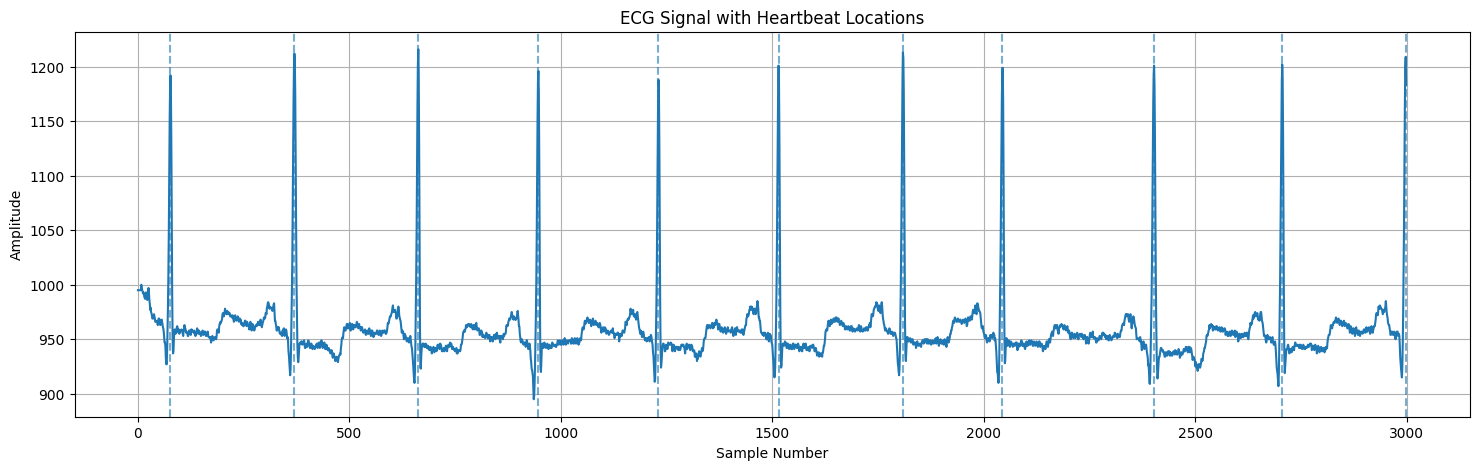

In [17]:
plt.figure(figsize=(18,5))

# Plot first 3000 ECG samples
plt.plot(record["'MLII'"][:3000], label="ECG Signal")

# Heartbeats occurring within first 3000 samples
first_beats = beat_annotations[
    beat_annotations["Sample"] < 3000
]

# Draw a vertical line for every heartbeat
for sample in first_beats["Sample"]:
    plt.axvline(sample,
                linestyle="--",
                alpha=0.6)

plt.title("ECG Signal with Heartbeat Locations")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [18]:
# Extract MLII signal as a NumPy array
ecg_signal = record["'MLII'"].values

print(type(ecg_signal))
print("Number of samples:", len(ecg_signal))
print(ecg_signal[:10])

<class 'numpy.ndarray'>
Number of samples: 650000
[ 995  995  995  995  995  995  995  995 1000  997]


In [19]:
# First heartbeat location
first_sample = beat_annotations.iloc[0]["Sample"]

print("Heartbeat location:", first_sample)

Heartbeat location: 77


In [20]:
second_sample = beat_annotations.iloc[1]["Sample"]

print(second_sample)

370


In [21]:
# Number of samples before and after R-peak
window = 100

# Extract heartbeat around sample 370
heartbeat = ecg_signal[
    second_sample - window :
    second_sample + window + 1
]

print("Heartbeat length:", len(heartbeat))
print(heartbeat[:10])

Heartbeat length: 201
[961 964 963 962 960 958 959 961 962 963]


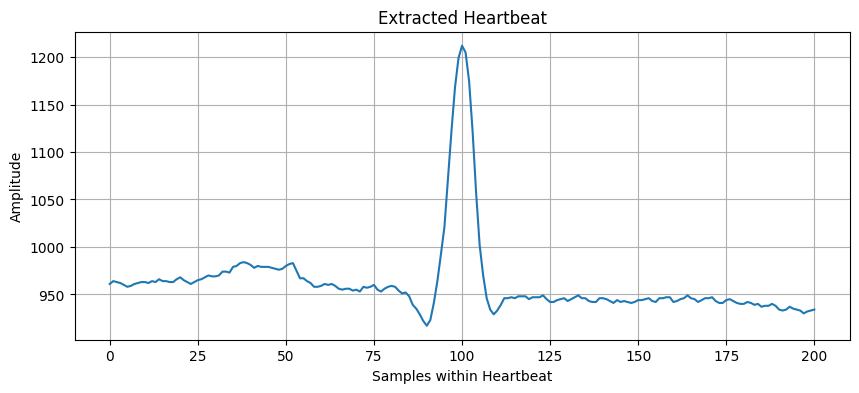

In [22]:
plt.figure(figsize=(10,4))

plt.plot(heartbeat)

plt.title("Extracted Heartbeat")
plt.xlabel("Samples within Heartbeat")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [23]:
def extract_heartbeat(signal, sample, window=100):
    """
    Extract one heartbeat around the R-peak.

    Parameters
    ----------
    signal : numpy array
        ECG signal

    sample : int
        R-peak location

    window : int
        Number of samples before and after R-peak

    Returns
    -------
    heartbeat : numpy array
        Extracted heartbeat
    """

    start = sample - window
    end = sample + window + 1

    return signal[start:end]

In [24]:
heartbeat = extract_heartbeat(
    ecg_signal,
    second_sample
)

print("Heartbeat length:", len(heartbeat))

Heartbeat length: 201


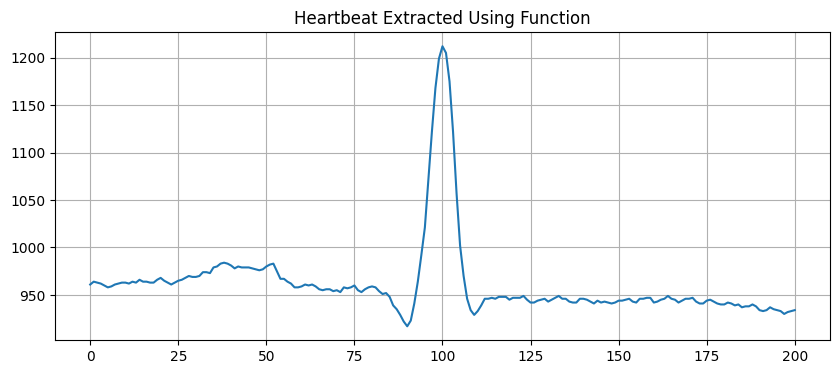

In [25]:
plt.figure(figsize=(10,4))

plt.plot(heartbeat)

plt.title("Heartbeat Extracted Using Function")

plt.grid(True)

plt.show()

In [26]:
for sample in beat_annotations["Sample"]:
    heartbeat = extract_heartbeat(
        ecg_signal,
        sample
    )

In [27]:
# Empty lists
heartbeats = []
labels = []

In [28]:
window = 100

for _, row in beat_annotations.iterrows():

    sample = row["Sample"]
    label = row["#"]

    # Skip beats too close to beginning or end
    if sample - window < 0:
        continue

    if sample + window >= len(ecg_signal):
        continue

    heartbeat = extract_heartbeat(
        ecg_signal,
        sample,
        window
    )

    heartbeats.append(heartbeat)
    labels.append(label)

In [29]:
print("Number of heartbeats:", len(heartbeats))
print("Number of labels:", len(labels))

print(labels[:10])

Number of heartbeats: 2271
Number of labels: 2271
['N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N']


In [30]:
# Convert heartbeat list into a DataFrame
heartbeat_df = pd.DataFrame(heartbeats)

# Add labels as the last column
heartbeat_df["Label"] = labels

heartbeat_df.head()

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,196,197,198,199,200,Label
0,961,964,963,962,960,958,959,961,962,963,...,934,937,935,934,933,930,932,933,934,N
1,955,955,955,958,958,957,955,954,954,956,...,937,938,937,940,940,940,940,939,939,N
2,951,955,955,956,953,951,952,953,953,953,...,949,951,950,947,945,947,947,950,951,N
3,954,954,954,956,956,955,955,948,952,952,...,933,932,936,937,939,938,935,934,935,N
4,958,961,961,958,958,957,957,958,958,958,...,936,937,938,938,934,935,935,937,937,N


In [31]:
print("Dataset Shape:", heartbeat_df.shape)

Dataset Shape: (2271, 202)


In [33]:
heartbeat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2271 entries, 0 to 2270
Columns: 202 entries, 0 to Label
dtypes: int64(201), object(1)
memory usage: 3.5+ MB


In [34]:
heartbeat_df["Label"].value_counts()

Label
N    2237
A      33
V       1
Name: count, dtype: int64

In [35]:
csv_files = sorted([
    file for file in os.listdir(dataset_path)
    if file.endswith(".csv")
])

print("Number of ECG files:", len(csv_files))

print(csv_files[:10])

Number of ECG files: 48
['100.csv', '101.csv', '102.csv', '103.csv', '104.csv', '105.csv', '106.csv', '107.csv', '108.csv', '109.csv']


In [36]:
annotation_files = sorted([
    file for file in os.listdir(dataset_path)
    if "annotations" in file
])

print("Number of annotation files:", len(annotation_files))

print(annotation_files[:10])

Number of annotation files: 48
['100annotations.txt', '101annotations.txt', '102annotations.txt', '103annotations.txt', '104annotations.txt', '105annotations.txt', '106annotations.txt', '107annotations.txt', '108annotations.txt', '109annotations.txt']


In [37]:
def read_record(record_id):
    """
    Read one ECG record.

    Parameters
    ----------
    record_id : str

    Returns
    -------
    DataFrame
    """

    file_path = f"{dataset_path}/{record_id}.csv"

    record = pd.read_csv(
        file_path,
        low_memory=False
    )

    return record

In [38]:
record100 = read_record("100")

print(record100.shape)

record100.head()

(650000, 3)


,'sample #','MLII','V5'
0,0,995,1011
1,1,995,1011
2,2,995,1011
3,3,995,1011
4,4,995,1011


In [52]:
def read_annotations(record_id):

    annotation_path = f"{dataset_path}/{record_id}annotations.txt"

    try:
        annotations = pd.read_csv(
            annotation_path,
            sep=r"\s+",
            engine="python"      # More tolerant parser
        )

        beat_annotations = annotations[
            annotations["#"] != "+"
        ]

        return beat_annotations

    except Exception as e:

        print(f"Skipping Record {record_id}")
        print(f"Reason: {e}")

        return None

In [53]:
ann100 = read_annotations("100")

print(ann100.shape)

ann100.head()

(2273, 8)


,Time,Sample,#,Type,Sub,Chan,Num,Aux
1,0:00.214,77,N,0,0,0,None,NaN
2,0:01.028,370,N,0,0,0,None,NaN
3,0:01.839,662,N,0,0,0,None,NaN
4,0:02.628,946,N,0,0,0,None,NaN
5,0:03.419,1231,N,0,0,0,None,NaN


In [54]:
mlii_records = []
non_mlii_records = []

for file in csv_files:

    record_id = file.replace(".csv", "")

    record = read_record(record_id)

    if "'MLII'" in record.columns:
        mlii_records.append(record_id)
    else:
        non_mlii_records.append(record_id)

print("Records with MLII:", len(mlii_records))
print(mlii_records)

print("\nRecords without MLII:", len(non_mlii_records))
print(non_mlii_records)

Records with MLII: 46
['100', '101', '103', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

Records without MLII: 2
['102', '104']


In [55]:
def extract_heartbeat(signal, sample, window=100):

    start = sample - window
    end = sample + window + 1

    return signal[start:end]

In [56]:
def process_record(record_id, window=100):

    record = read_record(record_id)

    # Skip records without MLII
    if "'MLII'" not in record.columns:
        print(f"Skipping Record {record_id} (No MLII)")
        return None

    # Get lead names
    lead1_name = record.columns[1]
    lead2_name = record.columns[2]

    lead1_signal = record[lead1_name].values
    lead2_signal = record[lead2_name].values

    beat_annotations = read_annotations(record_id)

    if beat_annotations is None:
        return None

    data = []

    for _, row in beat_annotations.iterrows():

        sample = row["Sample"]

        if sample - window < 0:
            continue

        if sample + window >= len(lead1_signal):
            continue

        hb1 = extract_heartbeat(lead1_signal, sample, window)
        hb2 = extract_heartbeat(lead2_signal, sample, window)

        combined = np.concatenate([hb1, hb2])

        data.append(
            [record_id] +
            combined.tolist() +
            [row["#"]]
        )

    columns = (
        ["Record_ID"] +
        [f"MLII_{i}" for i in range(201)] +
        [f"Lead2_{i}" for i in range(201)] +
        ["Label"]
    )

    return pd.DataFrame(data, columns=columns)

In [57]:
record100_df = process_record("100")

print(record100_df.shape)

record100_df.head()

(2271, 404)


,Record_ID,MLII_0,MLII_1,MLII_2,MLII_3,MLII_4,MLII_5,MLII_6,MLII_7,MLII_8,...,Lead2_192,Lead2_193,Lead2_194,Lead2_195,Lead2_196,Lead2_197,Lead2_198,Lead2_199,Lead2_200,Label
0,100,961,964,963,962,960,958,959,961,962,...,946,947,946,944,942,940,943,942,942,N
1,100,955,955,955,958,958,957,955,954,954,...,939,940,942,943,944,944,943,947,951,N
2,100,951,955,955,956,953,951,952,953,953,...,949,949,949,948,951,955,957,961,962,N
3,100,954,954,954,956,956,955,955,948,952,...,941,939,942,945,947,943,945,945,949,N
4,100,958,961,961,958,958,957,957,958,958,...,951,953,951,950,949,949,950,953,952,N


In [58]:
all_records = []

for record_id in mlii_records:

    print(f"Processing Record {record_id}...")

    df = process_record(record_id)

    if df is not None:
        all_records.append(df)

Processing Record 100...
Processing Record 101...
Processing Record 103...
Processing Record 105...
Processing Record 106...
Processing Record 107...
Processing Record 108...
Processing Record 109...
Processing Record 111...
Processing Record 112...
Processing Record 113...
Processing Record 114...
Processing Record 115...
Processing Record 116...
Processing Record 117...
Processing Record 118...
Processing Record 119...
Processing Record 121...
Processing Record 122...
Processing Record 123...
Processing Record 124...
Processing Record 200...
Processing Record 201...
Processing Record 202...
Processing Record 203...
Processing Record 205...
Processing Record 207...
Processing Record 208...
Processing Record 209...
Processing Record 210...
Processing Record 212...
Processing Record 213...
Processing Record 214...
Processing Record 215...
Processing Record 217...
Processing Record 219...
Processing Record 220...
Processing Record 221...
Processing Record 222...
Processing Record 223...


In [59]:
final_dataset = pd.concat(all_records, ignore_index=True)

print("Final Dataset Shape:")
print(final_dataset.shape)

Final Dataset Shape:
(106870, 404)


In [60]:
final_dataset.head()

,Record_ID,MLII_0,MLII_1,MLII_2,MLII_3,MLII_4,MLII_5,MLII_6,MLII_7,MLII_8,...,Lead2_192,Lead2_193,Lead2_194,Lead2_195,Lead2_196,Lead2_197,Lead2_198,Lead2_199,Lead2_200,Label
0,100,961,964,963,962,960,958,959,961,962,...,946,947,946,944,942,940,943,942,942,N
1,100,955,955,955,958,958,957,955,954,954,...,939,940,942,943,944,944,943,947,951,N
2,100,951,955,955,956,953,951,952,953,953,...,949,949,949,948,951,955,957,961,962,N
3,100,954,954,954,956,956,955,955,948,952,...,941,939,942,945,947,943,945,945,949,N
4,100,958,961,961,958,958,957,957,958,958,...,951,953,951,950,949,949,950,953,952,N


In [61]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106870 entries, 0 to 106869
Columns: 404 entries, Record_ID to Label
dtypes: int64(402), object(2)
memory usage: 329.4+ MB


In [62]:
final_dataset["Label"].value_counts()

Label
N    74766
L     8073
R     7257
V     7123
/     3619
A     2546
F      802
~      577
!      472
"      437
f      260
j      229
x      193
a      150
|      132
E      106
J       83
e       16
Q       15
[        6
]        6
S        2
Name: count, dtype: int64

In [63]:
print("Number of Records Used:", final_dataset["Record_ID"].nunique())

Number of Records Used: 46


In [64]:
final_dataset.to_csv(
    "MITBIH_MLII_DualLead_Dataset.csv",
    index=False
)